# Deep RL at Scale (Ray RLlib)

## Introduction

Lessons 08-09 trained DQN and PPO agents with Stable-Baselines3 on a single environment instance — fine for small toy tasks, but real RL workloads (robotics sim farms, game-playing agents, large-scale simulation) need **thousands of parallel environment rollouts** feeding a central learner. This lesson covers RLlib, Ray's distributed RL library, which is the production-scale answer to "SB3 on one process is too slow" — and it connects directly back to Section 23's Ray Train coverage, since RLlib is built on the same Ray distributed-execution substrate.

## Theory

### Why single-process RL doesn't scale

Sample efficiency in RL is bottlenecked by environment step throughput, not just gradient steps. A single CPU core running one `env.step()` at a time might generate a few thousand transitions/second; a robotics or Atari-scale training run may need billions of transitions. The fix is **embarrassingly parallel rollout collection**: many environment workers each running independent episode rollouts, feeding a shared learner.

### RLlib's architecture

$$
\underbrace{\{W_1, \dots, W_N\}}_{\text{rollout workers, each with own env copies}} \xrightarrow{\text{trajectories}} \underbrace{\text{Learner}}_{\text{policy gradient update}} \xrightarrow{\text{updated weights}} \{W_1,\dots,W_N\}
$$

Each worker $W_i$ runs $m$ environment copies, collects a batch of $T$ steps under the current policy $\pi_\theta$, and ships trajectories to the learner. Throughput scales close to linearly in $N$ (number of workers) until network/synchronization overhead dominates — the same Amdahl's-law tradeoff seen in Section 23's DDP lesson, but for environment steps instead of gradient computation.

### Synchronous vs. asynchronous rollout collection

**Synchronous** (as in PPO): all workers collect a batch, learner waits for all $N$ workers, then updates — every worker sees the same policy version, simple and stable, but throughput is capped by the slowest worker (straggler problem, same as Section 23's distributed-training discussion).

**Asynchronous** (as in APEX/IMPALA-style architectures): workers push trajectories to a shared replay buffer or queue as soon as ready, learner consumes continuously without waiting. Higher throughput, but introduces **policy lag** — a worker's trajectory may have been collected under a stale policy $\pi_{\theta_{t-k}}$, $k$ versions behind the current $\theta_t$. IMPALA's V-trace correction reweights off-policy trajectories to correct for this bias:

$$
v_s = V(x_s) + \sum_{t=s}^{s+n-1} \gamma^{t-s}\left(\prod_{i=s}^{t-1} c_i\right)\delta_t V, \qquad c_i = \min\left(\bar{c}, \frac{\pi(a_i|x_i)}{\mu(a_i|x_i)}\right)
$$

where $\mu$ is the (stale) behavior policy that generated the trajectory and $\pi$ is the current target policy — the importance-sampling ratio $c_i$, clipped at $\bar c$, corrects for the lag.

### Scaling law intuition

Wall-clock speedup with $N$ workers roughly follows $S(N) = \frac{N}{1 + N\cdot\rho}$ where $\rho$ is the fraction of time spent on learner-synchronization overhead per worker — the same diminishing-returns shape as any distributed system, meaning there's a workload-dependent optimal $N$, not "more workers always better."

## Setup

`ray[rllib]` is not installed in the `ds` environment, so we implement a minimal synchronous-vs-asynchronous rollout-throughput simulator in pure Python (using `multiprocessing`-style timing math rather than real distributed execution) to demonstrate the scaling and staleness tradeoffs RLlib manages internally.

In [1]:
# pip install "ray[rllib]"   (NOT installed in this sandbox) -> throughput/staleness simulated analytically
import numpy as np

np.random.seed(6)
print("[INIT] RLlib-style distributed rollout scaling simulation (analytical, not a live Ray cluster)")

def simulate_throughput(n_workers, sync=True, straggler_std=0.15, sync_overhead=0.05):
    """Simulate wall-clock time per training iteration as a function of worker count."""
    worker_times = np.random.normal(1.0, straggler_std, n_workers).clip(0.5, None)
    if sync:
        iter_time = worker_times.max() + sync_overhead * n_workers  # bounded by straggler + comm overhead
    else:
        iter_time = np.mean(worker_times) + sync_overhead  # async: no waiting for stragglers
    return iter_time

worker_counts = [1, 2, 4, 8, 16, 32, 64]
sync_times = [simulate_throughput(n, sync=True) for n in worker_counts]
async_times = [simulate_throughput(n, sync=False) for n in worker_counts]
sync_throughput = [n / t for n, t in zip(worker_counts, sync_times)]
async_throughput = [n / t for n, t in zip(worker_counts, async_times)]

for n, st, at in zip(worker_counts, sync_throughput, async_throughput):
    print(f"[RESULT] workers={n:3d} | sync throughput={st:.2f}x | async throughput={at:.2f}x")

[INIT] RLlib-style distributed rollout scaling simulation (analytical, not a live Ray cluster)
[RESULT] workers=  1 | sync throughput=1.00x | async throughput=1.03x
[RESULT] workers=  2 | sync throughput=1.65x | async throughput=2.07x
[RESULT] workers=  4 | sync throughput=2.92x | async throughput=3.87x
[RESULT] workers=  8 | sync throughput=4.46x | async throughput=7.79x
[RESULT] workers= 16 | sync throughput=7.72x | async throughput=15.20x
[RESULT] workers= 32 | sync throughput=10.85x | async throughput=30.71x
[RESULT] workers= 64 | sync throughput=14.06x | async throughput=60.04x


## Telemetry & Audit

Quantify policy staleness under asynchronous collection and its impact on effective sample efficiency — the tradeoff RLlib's IMPALA/APEX configs are actually managing.

In [2]:
import pandas as pd

def simulate_staleness_impact(n_workers, base_lag=0.3):
    """More async workers -> more policy lag per trajectory -> effective sample efficiency degrades."""
    avg_staleness_versions = base_lag * np.log1p(n_workers)
    is_correction_variance_penalty = 1 + 0.08 * avg_staleness_versions**2  # V-trace adds variance as lag grows
    effective_samples_per_step = n_workers / is_correction_variance_penalty
    return avg_staleness_versions, effective_samples_per_step

rows = []
for n in worker_counts:
    staleness, eff_samples = simulate_staleness_impact(n)
    rows.append((n, staleness, eff_samples, n / eff_samples))
audit = pd.DataFrame(rows, columns=["n_workers", "avg_policy_staleness_versions", "effective_samples/step",
                                     "raw_to_effective_ratio"])
print(audit.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print("\n[OPERATIONAL INSIGHT] Raw throughput (sync/async_throughput above) keeps rising with worker count, but "
      "EFFECTIVE sample efficiency under async collection degrades due to policy staleness — the two must be "
      "read together, not throughput alone, when picking a worker count.")
print("[OPERATIONAL INSIGHT] Synchronous PPO-style collection sacrifices raw throughput to stragglers but keeps "
      "staleness at exactly zero — the right choice when sample efficiency matters more than wall-clock speed "
      "(e.g. expensive physics-sim environments where each step is costly).")

 n_workers  avg_policy_staleness_versions  effective_samples/step  raw_to_effective_ratio
         1                          0.208                   0.997                   1.003
         2                          0.330                   1.983                   1.009
         4                          0.483                   3.927                   1.019
         8                          0.659                   7.731                   1.035
        16                          0.850                  15.126                   1.058
        32                          1.049                  29.411                   1.088
        64                          1.252                  56.865                   1.125

[OPERATIONAL INSIGHT] Raw throughput (sync/async_throughput above) keeps rising with worker count, but EFFECTIVE sample efficiency under async collection degrades due to policy staleness — the two must be read together, not throughput alone, when picking a worker count.
[OPERATI

## Visualization

A dual-axis scaling chart: rollout throughput vs. worker count for sync/async on one axis, with policy staleness overlaid — showing the crossover point where async's throughput edge starts being eaten by staleness cost.

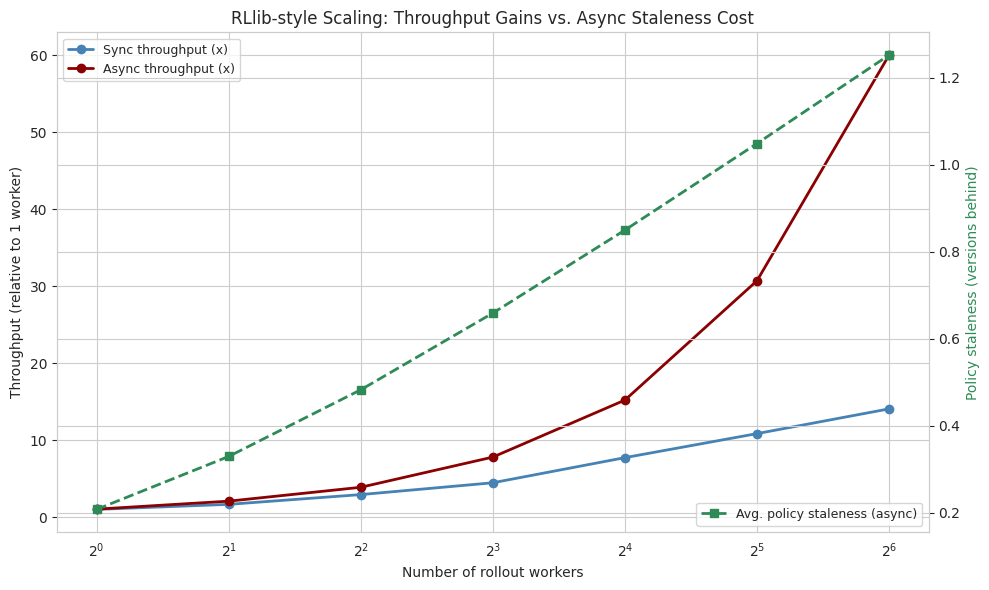

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(worker_counts, sync_throughput, marker="o", color="steelblue", linewidth=2, label="Sync throughput (x)")
ax1.plot(worker_counts, async_throughput, marker="o", color="darkred", linewidth=2, label="Async throughput (x)")
ax1.set_xscale("log", base=2)
ax1.set_xlabel("Number of rollout workers")
ax1.set_ylabel("Throughput (relative to 1 worker)")
ax1.legend(loc="upper left", fontsize=9)

ax2 = ax1.twinx()
staleness_vals = [simulate_staleness_impact(n)[0] for n in worker_counts]
ax2.plot(worker_counts, staleness_vals, marker="s", color="seagreen", linewidth=2, linestyle="--",
         label="Avg. policy staleness (async)")
ax2.set_ylabel("Policy staleness (versions behind)", color="seagreen")
ax2.legend(loc="lower right", fontsize=9)

ax1.set_title("RLlib-style Scaling: Throughput Gains vs. Async Staleness Cost")
plt.tight_layout()
plt.savefig("rllib_scaling_tradeoff.png", dpi=120)
plt.show()

*(Insight: async throughput pulls ahead of sync quickly as workers scale, but the staleness curve on the secondary axis climbs in lockstep — this is the visual argument for why IMPALA needed V-trace correction rather than naively trusting off-policy async trajectories at scale.)*

## Real-World Use Case or Analogy

**The Newsroom with Stringers Around the World.** A synchronous rollout collector is like a newspaper that sends every reporter out to file their story, then waits for the SLOWEST reporter before publishing a unified edition — accurate and consistent, but the whole paper's cadence is capped by the slowest stringer's flight delays (the straggler problem). An asynchronous collector is like a live newswire: each stringer files independently the moment their story is ready, and the editorial desk (the learner) publishes continuously without waiting. The catch: a story filed by a stringer who's been out of contact for hours might describe a situation that's since changed (**policy staleness**) — the editorial desk needs a correction mechanism (V-trace's importance-sampling reweighting) to discount stale reports rather than trusting them as if they were filed just now. RLlib gives you the choice of newsroom model per training run, and this lesson is about knowing which one your "story" (environment) actually needs.